In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
salary_prediction = pd.read_csv('data/Salary_Data.csv')

In [3]:
x_train = salary_prediction['YearsExperience'].values
y_train = salary_prediction['Salary'].values

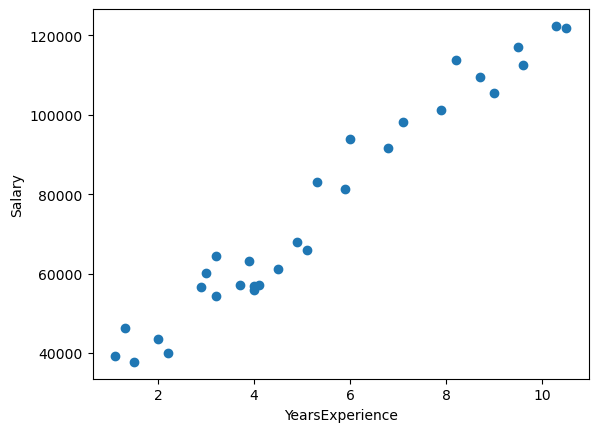

In [4]:
plt.scatter(x_train, y_train)
plt.xlabel('YearsExperience')
plt.ylabel('Salary')
plt.show()

## Cost function

Linear regression predicts:

$$f(x) = w \cdot x + b$$

To measure how good a given `w` and `b` are, we use the **Mean Squared Error** cost function:

$$J(w, b) = \frac{1}{2m} \sum_{i=1}^{m} \left(f(x_i) - y_i\right)^2$$

- `m` is the number of training examples
- The squared term penalizes larger errors more heavily
- The `1/2` is a convenience factor that cancels out nicely when taking the derivative (see the gradient below)

Smaller cost = better fit. Training means finding the `w` and `b` that minimize this.

In [5]:
def cost_function(x, y, w, b):
    m = len(x)
    cost_value = 0

    for i in range(m):
        f = w * x[i] + b
        cost = (f - y[i]) ** 2
        cost_value += cost

    total_cost = (1 / (2 * m)) * cost_value

    return total_cost

## Gradients

To minimize the cost function, we need to know which direction to adjust `w` and `b` in. That's what the gradient (partial derivatives) tells us:

$$\frac{\partial J}{\partial w} = \frac{1}{m} \sum_{i=1}^{m} \left(f(x_i) - y_i\right) \cdot x_i$$

$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} \left(f(x_i) - y_i\right)$$

We move `w` and `b` in the *opposite* direction of the gradient to reduce the cost.

In [6]:
def gradient_function(x, y, w, b):
    m = len(x)
    dc_dw = 0
    dc_db = 0

    for i in range(m):
        f = w * x[i] + b

        dc_dw += (f - y[i]) * x[i]
        dc_db += (f - y[i])

    dc_dw = (1 / m) * dc_dw
    dc_db = (1 / m) * dc_db

    return dc_dw, dc_db

## Gradient descent

Starting from `w = 0` and `b = 0`, repeatedly nudge `w` and `b` in the direction that reduces the cost:

$$w := w - \alpha \cdot \frac{\partial J}{\partial w}$$

$$b := b - \alpha \cdot \frac{\partial J}{\partial b}$$

`alpha` (the learning rate) controls the step size, and we repeat the update for a fixed number of `iterations`.

In [7]:
def gradient_descent(x, y, alpha, iterations):
    w = 0
    b = 0

    for i in range(iterations):
        dc_dw, dc_db = gradient_function(x, y, w, b)

        w = w - alpha * dc_dw
        b = b - alpha * dc_db

        #print(f"iteration {i} : cost {cost_function(x,y,w,b)}")

    return w, b

In [8]:
iterations = 10000
learning_rate = 0.01

final_w, final_b = gradient_descent(x_train, y_train, learning_rate, iterations)

print(f'w: {final_w:.4f}, b: {final_b:.4f}')

w: 9449.9623, b: 25792.2002


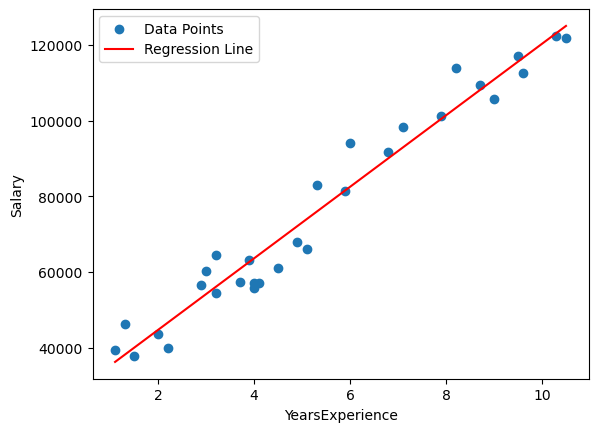

In [9]:
plt.scatter(x_train, y_train, label='Data Points')

x_vals = np.linspace(min(x_train), max(x_train), 100)
y_vals = final_w * x_vals + final_b
plt.plot(x_vals, y_vals, color='Red', label='Regression Line')

plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.legend()
plt.show()

## Evaluation

MAE, MSE and R² computed manually with `numpy` — no sklearn.

In [10]:
prediction = final_w * x_train + final_b

# Mean Absolute Error
mae = np.mean(np.abs(y_train - prediction))

# Mean Squared Error
mse = np.mean((y_train - prediction) ** 2)

# R-squared
ss_res = np.sum((y_train - prediction) ** 2)
ss_tot = np.sum((y_train - np.mean(y_train)) ** 2)
r2 = 1 - (ss_res / ss_tot)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R2: {r2:.4f}")

MAE: 4644.20
MSE: 31270951.72
R2: 0.9570


In [11]:
six_years = final_w * 6 + final_b
print(f'predicted salary: £{six_years:.2f}')

predicted salary: £82491.97
